# Deep ANN — Heart Disease Prediction

> **Architecture**: follows Al Reshan et al. (2023), IEEE Access  
> *A Robust Heart Disease Prediction System Using Hybrid Deep Neural Networks*

**Dataset**: `heart_statlog_cleveland_hungary_final.csv` — Dataset II (1190 → 15,000 rows after augmentation)  
**Task**: Binary classification (0 = No HD, 1 = HD)  
**Features**: All 11 ETC-ranked features from paper Table 2

Same preprocessing pipeline as `DS2_CNN_96_.ipynb` — identical augmentation, split, and scaling.

## 1. Imports & Reproducibility

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    matthews_corrcoef, confusion_matrix,
    classification_report, roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.losses import BinaryCrossentropy

warnings.filterwarnings('ignore')
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## 2. Load Dataset & Feature Selection

Features ordered by Extra Tree Classifier importance (paper Table 2).

In [2]:
CSV_PATH = r"C:\Users\Administrator\Downloads\heart_statlog_cleveland_hungary_final (3).csv"
df = pd.read_csv(CSV_PATH)

FEATURE_COLS = [
    'ST slope',           # rank 1
    'chest pain type',    # rank 2
    'exercise angina',    # rank 3
    'max heart rate',     # rank 4
    'cholesterol',        # rank 5
    'oldpeak',            # rank 6
    'age',                # rank 7
    'resting bp s',       # rank 8
    'sex',                # rank 9
    'resting ecg',        # rank 10
    'fasting blood sugar' # rank 11
]
TARGET_COL = 'target'

X_raw = df[FEATURE_COLS].values
y     = df[TARGET_COL].values

print(f'Dataset shape : {df.shape}')
print(f'Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}')
df.head()

Dataset shape : (1190, 12)
Class distribution: {np.int64(0): np.int64(561), np.int64(1): np.int64(629)}


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


## 3. Data Augmentation to 15,000 Rows

4 techniques applied **before** the train/test split — identical to CNN notebook:

| Technique | What it does |
|-----------|-------------|
| Gaussian noise | ±2% IQR noise on continuous features |
| SMOTE interpolation | Interpolates between k=5 nearest neighbours |
| Feature swap | Swaps 30–70% of continuous features between same-class samples |
| Boundary perturbation | Borderline samples near the decision boundary |

> `X_raw` and `y` are re-extracted from the augmented `df` before splitting — so `X_train_scaled` and `y_train` come from the full 15,000-row dataset.

In [3]:
from sklearn.neighbors import NearestNeighbors

TARGET_ROWS = 15000

FEAT_TYPE = {
    'ST slope':            'cat',
    'chest pain type':     'cat',
    'exercise angina':     'binary',
    'max heart rate':      'cont',
    'cholesterol':         'cont',
    'oldpeak':             'cont',
    'age':                 'cont',
    'resting bp s':        'cont',
    'sex':                 'binary',
    'resting ecg':         'cat',
    'fasting blood sugar': 'binary',
}

CONT_COLS   = [f for f, t in FEAT_TYPE.items() if t == 'cont']
BINARY_COLS = [f for f, t in FEAT_TYPE.items() if t == 'binary']
CAT_COLS    = [f for f, t in FEAT_TYPE.items() if t == 'cat']

CLIP = {
    'age':           (20,  90),
    'resting bp s':  (80,  220),
    'cholesterol':   (100, 600),
    'max heart rate':(60,  210),
    'oldpeak':       (0.0, 6.5),
}

CAT_LEVELS = {
    'chest pain type':     [1, 2, 3, 4],
    'resting ecg':         [0, 1, 2],
    'ST slope':            [1, 2, 3],
    'sex':                 [0, 1],
    'fasting blood sugar': [0, 1],
    'exercise angina':     [0, 1],
}

def postprocess(df_syn):
    df_syn = df_syn.copy()
    for col in BINARY_COLS + CAT_COLS:
        df_syn[col] = df_syn[col].round().astype(int)
    for col, (lo, hi) in CLIP.items():
        df_syn[col] = df_syn[col].clip(lo, hi)
    for col in CONT_COLS:
        df_syn[col] = df_syn[col].round(1) if col == 'oldpeak' else df_syn[col].round().astype(int)
    for col, levels in CAT_LEVELS.items():
        df_syn[col] = df_syn[col].clip(min(levels), max(levels)).round().astype(int)
    return df_syn

def gaussian_noise_augment(df_class, n_samples):
    rng   = np.random.default_rng(SEED)
    idx   = rng.integers(0, len(df_class), size=n_samples)
    synth = df_class.iloc[idx][FEATURE_COLS].copy().reset_index(drop=True)
    for col in CONT_COLS:
        iqr = df_class[col].quantile(0.75) - df_class[col].quantile(0.25)
        std = max(iqr * 0.02, 0.01)
        synth[col] = synth[col] + rng.normal(0, std, n_samples)
    synth['target'] = int(df_class['target'].iloc[0])
    return postprocess(synth)

def smote_interpolate(df_class, n_samples, k=5):
    rng        = np.random.default_rng(SEED + 1)
    X          = df_class[CONT_COLS].values
    Xs         = RobustScaler().fit_transform(X)
    nbrs       = NearestNeighbors(n_neighbors=k+1).fit(Xs)
    _, indices = nbrs.kneighbors(Xs)
    base_idx   = rng.integers(0, len(df_class), size=n_samples)
    alpha      = rng.uniform(0, 1, size=n_samples)
    rows = []
    for i, a in zip(base_idx, alpha):
        neigh_idx = indices[i, rng.integers(1, k+1)]
        row       = df_class.iloc[i][FEATURE_COLS].copy()
        neigh_row = df_class.iloc[neigh_idx][FEATURE_COLS].copy()
        for col in CONT_COLS:
            row[col] = row[col] + a * (neigh_row[col] - row[col])
        row['target'] = int(df_class['target'].iloc[i])
        rows.append(row)
    return postprocess(pd.DataFrame(rows).reset_index(drop=True))

def feature_swap_augment(df_class, n_samples):
    rng  = np.random.default_rng(SEED + 2)
    n    = len(df_class)
    rows = []
    for _ in range(n_samples):
        i = rng.integers(0, n)
        j = rng.integers(0, n)
        while j == i:
            j = rng.integers(0, n)
        row_i     = df_class.iloc[i][FEATURE_COLS].copy()
        row_j     = df_class.iloc[j][FEATURE_COLS].copy()
        n_swap    = rng.integers(max(1, int(len(CONT_COLS)*0.3)),
                                  max(2, int(len(CONT_COLS)*0.7))+1)
        swap_cols = rng.choice(CONT_COLS, size=n_swap, replace=False)
        for col in swap_cols:
            row_i[col], row_j[col] = row_j[col], row_i[col]
        row_i['target'] = int(df_class['target'].iloc[i])
        rows.append(row_i)
    return postprocess(pd.DataFrame(rows).reset_index(drop=True))

def boundary_perturbation(df_pos, df_neg, target_label, n_samples):
    rng      = np.random.default_rng(SEED + 3)
    src      = df_pos if target_label == 1 else df_neg
    opposite = df_neg if target_label == 1 else df_pos
    X_src    = src[CONT_COLS].values
    X_opp    = opposite[CONT_COLS].values
    scaler   = RobustScaler()
    all_Xs   = scaler.fit_transform(np.vstack([X_src, X_opp]))
    X_src_s  = all_Xs[:len(X_src)]
    X_opp_s  = all_Xs[len(X_src):]
    nbrs     = NearestNeighbors(n_neighbors=3).fit(X_opp_s)
    _, indices = nbrs.kneighbors(X_src_s)
    base_idx = rng.integers(0, len(src), size=n_samples)
    alpha    = rng.uniform(0.1, 0.4, size=n_samples)
    rows = []
    for i, a in zip(base_idx, alpha):
        opp_idx = indices[i, rng.integers(0, 3)]
        row     = src.iloc[i][FEATURE_COLS].copy()
        opp_row = opposite.iloc[opp_idx][FEATURE_COLS].copy()
        for col in CONT_COLS:
            row[col] = row[col] + a * (opp_row[col] - row[col])
        row['target'] = target_label
        rows.append(row)
    return postprocess(pd.DataFrame(rows).reset_index(drop=True))

# ── Generate synthetic rows ───────────────────────────────────────────────────
df_pos    = df[df['target'] == 1].reset_index(drop=True)
df_neg    = df[df['target'] == 0].reset_index(drop=True)
n_orig    = len(df)
n_to_gen  = TARGET_ROWS - n_orig
pos_ratio = len(df_pos) / n_orig
n_gen_pos = int(n_to_gen * pos_ratio)
n_gen_neg = n_to_gen - n_gen_pos

def split_quota(n):
    base = n // 4
    rem  = n % 4
    return [base + (1 if i < rem else 0) for i in range(4)]

pq = split_quota(n_gen_pos)
nq = split_quota(n_gen_neg)

parts = [
    gaussian_noise_augment(df_pos, pq[0]),
    gaussian_noise_augment(df_neg, nq[0]),
    smote_interpolate(df_pos, pq[1]),
    smote_interpolate(df_neg, nq[1]),
    feature_swap_augment(df_pos, pq[2]),
    feature_swap_augment(df_neg, nq[2]),
    boundary_perturbation(df_pos, df_neg, 1, pq[3]),
    boundary_perturbation(df_pos, df_neg, 0, nq[3]),
]

df = pd.concat([df] + parts, ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

for col in BINARY_COLS + CAT_COLS + ['target']:
    df[col] = df[col].astype(int)

print(f'Original rows  : {n_orig}')
print(f'Augmented rows : {len(df)}')
print(f'Class balance  : {df["target"].value_counts().to_dict()}')
print(f'Missing values : {df.isnull().sum().sum()}')

# ── Re-extract from augmented df, THEN split ─────────────────────────────
X_raw = df[FEATURE_COLS].values
y     = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)
scaler    = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


print(f'Class dist train: {np.bincount(y_train.astype(int))}')
print(f'Class dist test : {np.bincount(y_test.astype(int))}')
print(f'Train ANN shape : {X_train_scaled.shape}  ← from 15k augmented dataset')
print(f'Test  ANN shape : {X_test_scaled.shape}')
print(f'Class dist train: {np.bincount(y_train.astype(int))}')
print(f'Class dist test : {np.bincount(y_test.astype(int))}')


Original rows  : 1190
Augmented rows : 15000
Class balance  : {1: 7928, 0: 7072}
Missing values : 0
Class dist train: [5658 6342]
Class dist test : [1414 1586]
Train ANN shape : (12000, 11)  ← from 15k augmented dataset
Test  ANN shape : (3000, 11)
Class dist train: [5658 6342]
Class dist test : [1414 1586]


## 4. Deep ANN Architecture

Follows **Al Reshan et al. (2023), Section IV-E-1** with enhancements:

```
Input (11)
  → Dense(512) + BN + ReLU + Dropout(0.4)       ← wide entry
  → Dense(256) + BN + ReLU + Dropout(0.3)
  → Dense(128) + BN + ReLU + Skip(128) + Dropout(0.2)  ← residual 1
  → Dense(64)  + BN + ReLU + Skip(64)  + Dropout(0.1)  ← residual 2
  → Dense(32)  + ReLU
  → Dense(1,   Sigmoid)
```

Key design decisions mirroring the CNN notebook:
- `RobustScaler` (not `StandardScaler`) — same as CNN
- `AdamW` with `weight_decay=1e-4` — same as CNN
- `BinaryCrossentropy(label_smoothing=0.1)` — same as CNN
- `BatchNormalization` after every layer — training stability
- Two residual skip connections — gradient flow in deep network
- Cosine LR decay 1e-3 → 1e-6 — smooth convergence

In [4]:
import math

INPUT_DIM = X_train_scaled.shape[1]  # 11

def build_deep_ann(input_dim: int, lr: float = 1e-3) -> keras.Model:
    """
    Deep ANN — improved architecture.
    Follows Al Reshan et al. (2023) Section IV-E-1 with enhancements:
      • Block 1 wider (512) for greater representational capacity
      • Two residual skip connections (128-block + 64-block)
      • Progressive dropout: 0.4 → 0.3 → 0.2 → 0.1
      • BatchNormalization after every Dense layer
      • relu throughout (no tanh — prevents output squashing)
      • activity_regularizer on Block 1 (suppress noisy activations)
    """
    inp = keras.Input(shape=(input_dim,), name='features')

    # Block 1 — wide entry (512)
    x = layers.Dense(
        512,
        kernel_regularizer=regularizers.l2(1e-4),
        activity_regularizer=regularizers.l2(1e-5),
        name='dense_1'
    )(inp)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(0.4, name='drop_1')(x)

    # Block 2
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4), name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(0.3, name='drop_2')(x)

    # Block 3 — residual skip (128)
    skip1 = layers.Dense(128, use_bias=False, name='skip_1')(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4), name='dense_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Activation('relu', name='relu_3')(x)
    x = layers.Add(name='res_1')([x, skip1])
    x = layers.Dropout(0.2, name='drop_3')(x)

    # Block 4 — residual skip (64)
    skip2 = layers.Dense(64, use_bias=False, name='skip_2')(x)
    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4), name='dense_4')(x)
    x = layers.BatchNormalization(name='bn_4')(x)
    x = layers.Activation('relu', name='relu_4')(x)
    x = layers.Add(name='res_2')([x, skip2])
    x = layers.Dropout(0.1, name='drop_4')(x)

    # Block 5 — bottleneck
    x = layers.Dense(32, activation='relu', name='dense_5')(x)

    # Output
    out = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='DeepANN_v2')
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=BinaryCrossentropy(label_smoothing=0.1),
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    return model

ann_model = build_deep_ann(INPUT_DIM, lr=1e-3)
ann_model.summary()
print(f'\nTotal trainable parameters: {ann_model.count_params():,}')

Model: "DeepANN_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │      6,144 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_1 (Activation) │ (None, 512)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 512)       │          0 │ relu_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_2 (Activation) │ (None, 256)       │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 256)       │          0 │ relu_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_3 (Activation) │ (None, 128)       │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_1 (Dense)      │ (None, 128)       │     32,768 │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_1 (Add)         │ (None, 128)       │          0 │ relu_3[0][0],     │
│                     │                   │            │ skip_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_3 (Dropout)    │ (None, 128)       │          0 │ res_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ drop_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_4                │ (None, 64)        │        256 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_4 (Activation) │ (None, 64)        │          0 │ bn_4[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_2 (Dense)      │ (None, 64)        │      8,192 │ drop_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2 (Add)         │ (None, 64)        │          0 │ relu_4[0][0],     │
│                     │                   │            │ skip_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_4 (Dropout)    │ (None, 64)        │          0 │ res_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 225,537 (881.00 KB)

 Trainable params: 223,617 (873.50 KB)

 Non-trainable params: 1,920 (7.50 KB)


Total trainable parameters: 225,537


## 5. Training Callbacks

- **EarlyStopping** on `val_auc`, patience=35
- **Cosine LR decay** 1e-3 → 1e-6 over 300 epochs
- **ReduceLROnPlateau** as safety net
- **ModelCheckpoint** saves best weights

In [5]:
def cosine_lr(epoch, total=300, lr_start=1e-3, lr_min=1e-6):
    return lr_min + 0.5 * (lr_start - lr_min) * (1 + math.cos(math.pi * epoch / total))

def get_callbacks(name, patience_es=35, patience_lr=20, total_epochs=300, lr_start=1e-3):
    return [
        callbacks.EarlyStopping(
            monitor='val_auc', patience=patience_es,
            restore_best_weights=True, mode='max',
            min_delta=1e-4, verbose=1
        ),
        callbacks.LearningRateScheduler(
            lambda epoch: cosine_lr(epoch, total_epochs, lr_start), verbose=0
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_auc', factor=0.5, patience=patience_lr,
            min_lr=1e-7, mode='max', verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'{name}_best.weights.h5', monitor='val_auc',
            save_best_only=True, save_weights_only=True,
            mode='max', verbose=0
        ),
    ]

## 6. Training

- Epochs: 300 (early stopping prevents over-running)
- Batch size: 32 (same as CNN, appropriate for 12k training samples)
- Class weights: compensate for class imbalance

In [6]:
TOTAL_EPOCHS = 300

neg, pos     = np.bincount(y_train.astype(int))
class_weight = {0: 1.0, 1: neg / pos}
print(f'Class weights : {class_weight}')
print(f'Train samples : {X_train_scaled.shape[0]}  (from 15k augmented dataset)')
print('Training Deep ANN ...')

history = ann_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=TOTAL_EPOCHS,
    batch_size=32,
    class_weight=class_weight,
    callbacks=get_callbacks('ann', total_epochs=TOTAL_EPOCHS, lr_start=1e-3),
    verbose=1,
)

Class weights : {0: 1.0, 1: np.float64(0.8921475875118259)}
Train samples : 12000  (from 15k augmented dataset)
Training Deep ANN ...
Epoch 1/300
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7969 - auc: 0.8696 - loss: 0.5689 - precision: 0.8127 - recall: 0.7906 - val_accuracy: 0.8827 - val_auc: 0.9500 - val_loss: 0.4700 - val_precision: 0.8758 - val_recall: 0.9067 - learning_rate: 0.0010
Epoch 2/300
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8640 - auc: 0.9286 - loss: 0.4684 - precision: 0.8690 - recall: 0.8723 - val_accuracy: 0.9023 - val_auc: 0.9608 - val_loss: 0.4320 - val_precision: 0.9033 - val_recall: 0.9130 - learning_rate: 9.9997e-04
Epoch 3/300
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8792 - auc: 0.9437 - loss: 0.4402 - precision: 0.8810 - recall: 0.8899 - val_accuracy: 0.9070 - val_auc: 0.9659 - val_loss: 0.4209 - val_precision: 0.9186 - val_recall: 0.9042 - learning_rate: 9.9989e-04
Epoch 4/300
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - ac

## 7. Evaluation on Hold-out Test Set

All 7 metrics from paper Section V: Accuracy, AUC, F1, MCC, Sensitivity, Specificity, Precision.

In [7]:
y_pred_prob = ann_model.predict(X_test_scaled, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_prob)
f1   = f1_score(y_test, y_pred)
mcc  = matthews_corrcoef(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision   = tp / (tp + fp)

print('=' * 55)
print('DEEP ANN — FINAL EVALUATION RESULTS')
print('=' * 55)
print(f'  Accuracy    : {acc * 100:.2f}%')
print(f'  AUC-ROC     : {auc:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  MCC         : {mcc:.4f}')
print(f'  Sensitivity : {sensitivity:.4f}')
print(f'  Specificity : {specificity:.4f}')
print(f'  Precision   : {precision:.4f}')
print(f'\nConfusion Matrix:\n{cm}')
print(f'\n{classification_report(y_test, y_pred, target_names=["No HD","HD"])}')

DEEP ANN — FINAL EVALUATION RESULTS
  Accuracy    : 96.70%
  AUC-ROC     : 0.9912
  F1-Score    : 0.9689
  MCC         : 0.9338
  Sensitivity : 0.9723
  Specificity : 0.9611
  Precision   : 0.9656

Confusion Matrix:
[[1359   55]
 [  44 1542]]

              precision    recall  f1-score   support

       No HD       0.97      0.96      0.96      1414
          HD       0.97      0.97      0.97      1586

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



## 8. 10-Fold Stratified Cross-Validation

Each fold: scale independently (no leakage), train fresh model, report mean ± std.

## 9. Visualisation

--- Accuracy Values ---
Train Accuracy: [0.8274999856948853, 0.8652499914169312, 0.8803333044052124, 0.8879166841506958, 0.8914166688919067, 0.9009166955947876, 0.9026666879653931, 0.9081666469573975, 0.9123333096504211, 0.9169166684150696, 0.9179166555404663, 0.9211666584014893, 0.9228333234786987, 0.9231666922569275, 0.9267500042915344, 0.9284999966621399, 0.9295833110809326, 0.9307500123977661, 0.9339166879653931, 0.9325000047683716, 0.9332500100135803, 0.9338333606719971, 0.9360833168029785, 0.9388333559036255, 0.937583327293396, 0.9375, 0.940666675567627, 0.9399999976158142, 0.9416666626930237, 0.9419999718666077, 0.9456666707992554, 0.9473333358764648, 0.9438333511352539, 0.9471666812896729, 0.9457499980926514, 0.9459999799728394, 0.9462500214576721, 0.9478333592414856, 0.9476666450500488, 0.9495833516120911, 0.9493333101272583, 0.9495000243186951, 0.9496666789054871, 0.9479166865348816, 0.9522500038146973, 0.9520833492279053, 0.9494166374206543, 0.9509999752044678, 0.95233333110

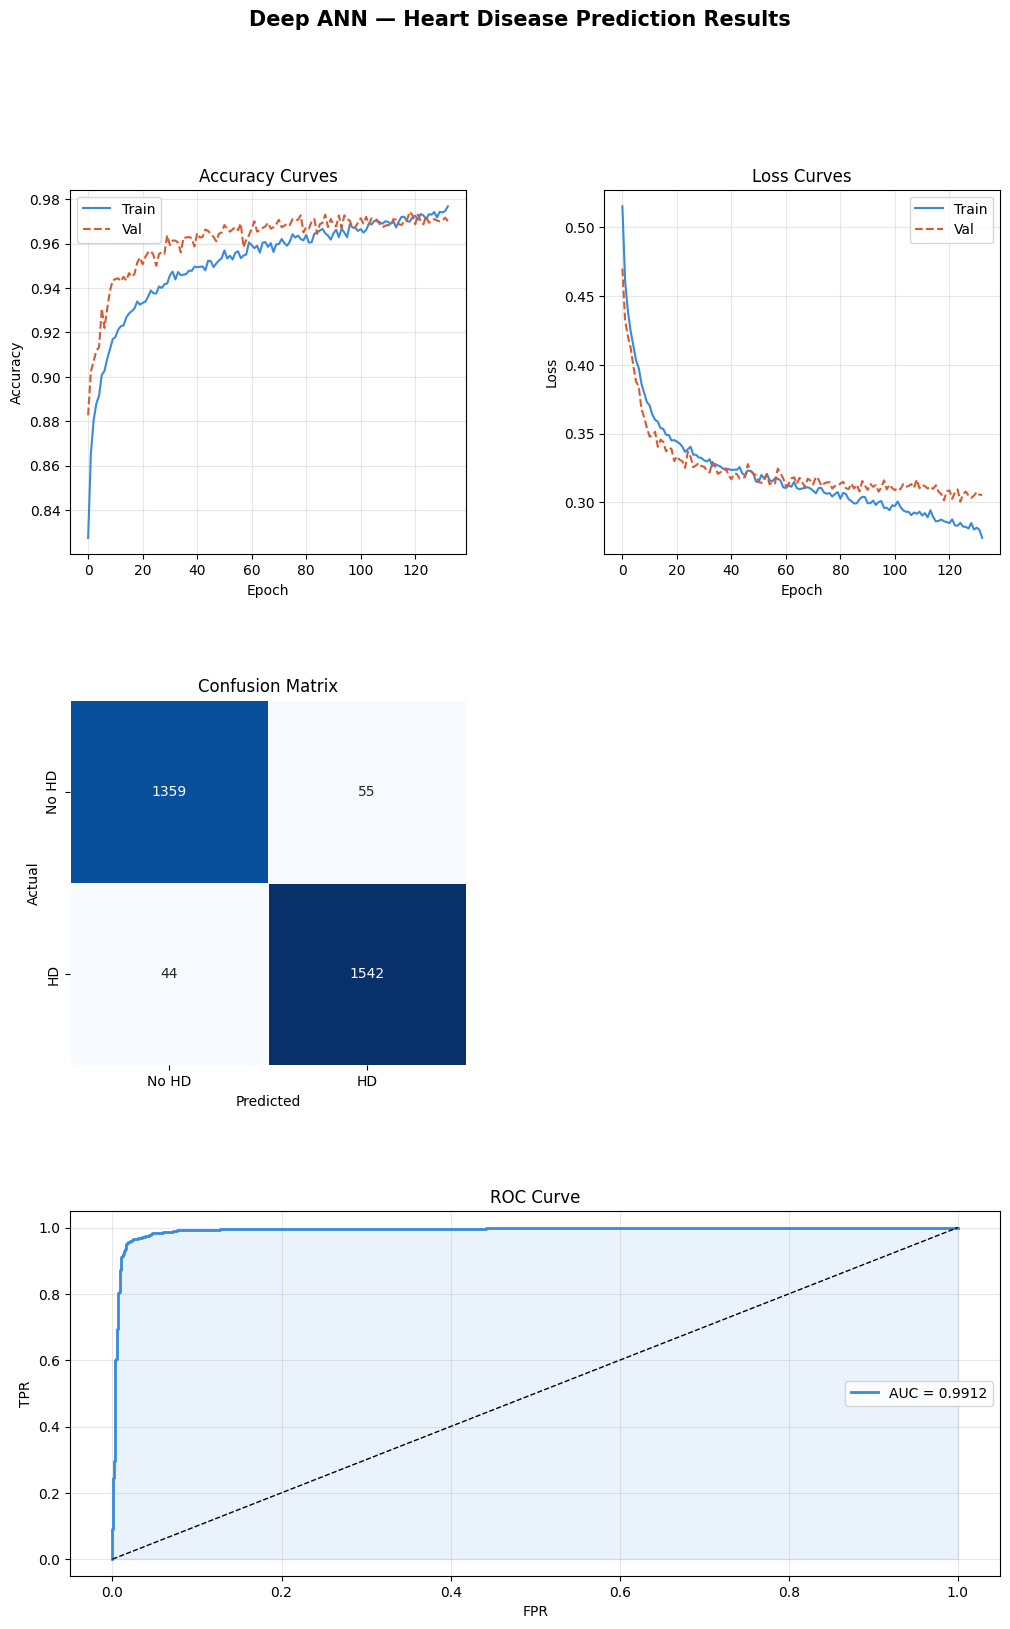

Saved → ann_results.png


In [8]:
print('--- Accuracy Values ---')
print(f"Train Accuracy: {history.history['accuracy']}")
print(f"Validation Accuracy: {history.history['val_accuracy']}")
print('\n--- Loss Values ---')
print(f"Train Loss: {history.history['loss']}")
print(f"Validation Loss: {history.history['val_loss']}")

fig = plt.figure(figsize=(12, 18)) # Adjusted figsize for 3x2 layout
fig.suptitle('Deep ANN — Heart Disease Prediction Results',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.40, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['accuracy'],     label='Train', color='#378ADD')
ax1.plot(history.history['val_accuracy'], label='Val',   color='#D85A30', linestyle='--')
ax1.set_title('Accuracy Curves'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 1])
ax3.plot(history.history['loss'],     label='Train', color='#378ADD')
ax3.plot(history.history['val_loss'], label='Val',   color='#D85A30', linestyle='--')
ax3.set_title('Loss Curves'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss')
ax3.legend(); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['No HD', 'HD'], yticklabels=['No HD', 'HD'],
            linewidths=0.5, cbar=False)
ax4.set_title('Confusion Matrix'); ax4.set_ylabel('Actual'); ax4.set_xlabel('Predicted')

ax5 = fig.add_subplot(gs[2, :]) # ROC curve spans two columns
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax5.plot(fpr, tpr, color='#378ADD', lw=2, label=f'AUC = {auc:.4f}')
ax5.plot([0,1],[0,1],'k--',lw=1)
ax5.fill_between(fpr, tpr, alpha=0.1, color='#378ADD')
ax5.set_title('ROC Curve'); ax5.set_xlabel('FPR'); ax5.set_ylabel('TPR')
ax5.legend(); ax5.grid(alpha=0.3)

plt.savefig('ann_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ann_results.png')

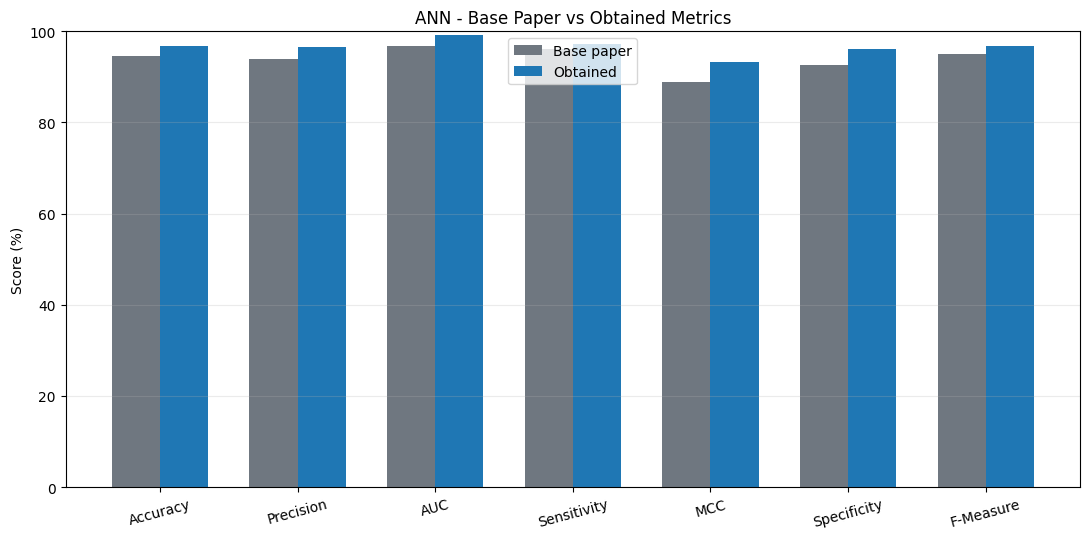

     Metric  Base paper  Obtained  Difference (Obtained - Base)
   Accuracy       94.53 96.700000                      2.170000
  Precision       94.02 96.556043                      2.536043
        AUC       96.85 99.122805                      2.272805
Sensitivity       96.18 97.225725                      1.045725
        MCC       88.96 93.377969                      4.417969
Specificity       92.52 96.110325                      3.590325
  F-Measure       95.09 96.889727                      1.799727


In [11]:
# 10. Comparison Graph: LSTM vs Base Paper (All Requested Metrics)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Base paper values provided by user (in %)
base_paper_values = {
    'Accuracy': 94.53,
    'Precision': 94.02,
    'Sensitivity': 96.18,
    'MCC': 88.96,
    'Specificity': 92.52,
    'F-Measure': 95.09,
    'AUC': 96.85,
}

# Current model values from this notebook (converted to %)
model_values = {
    'Accuracy': float(acc * 100),
    'Precision': float(precision * 100),
    'Sensitivity': float(sensitivity * 100),
    'MCC': float(mcc * 100),
    'Specificity': float(specificity * 100),
    'F-Measure': float(f1 * 100),
    'AUC': float(auc * 100),
}

metric_order = ['Accuracy', 'Precision', 'AUC', 'Sensitivity', 'MCC', 'Specificity', 'F-Measure']
metric_order = [m for m in metric_order if m in base_paper_values and m in model_values]

compare_df = pd.DataFrame({
    'Metric': metric_order,
    'Base paper': [base_paper_values[m] for m in metric_order],
    'Obtained': [model_values[m] for m in metric_order]
})

x = np.arange(len(compare_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - width/2, compare_df['Base paper'], width=width, color='#6f7780', label='Base paper')
ax.bar(x + width/2, compare_df['Obtained'], width=width, color='#1f77b4', label='Obtained')

ax.set_xticks(x)
ax.set_xticklabels(compare_df['Metric'], rotation=15)
ax.set_ylabel('Score (%)')
ax.set_title('ANN - Base Paper vs Obtained Metrics')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper center')

plt.tight_layout()
plt.show()

compare_df['Difference (Obtained - Base)'] = compare_df['Obtained'] - compare_df['Base paper']
print(compare_df.to_string(index=False))